In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score

In [3]:
df = pd.read_csv("Desktop/load.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
df.shape

(614, 13)

In [5]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [6]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [7]:
df = df.dropna()

In [8]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

<Axes: >

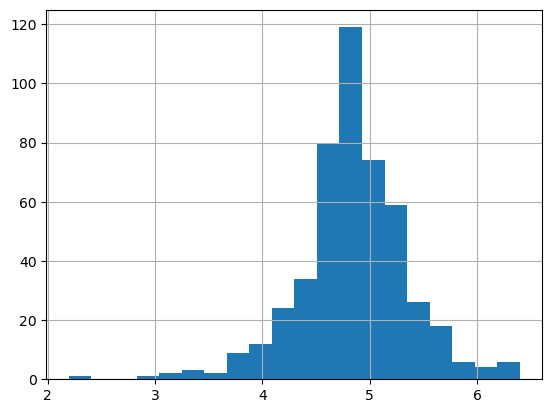

In [9]:
df['loanAmount_log']= np.log(df["LoanAmount"])
df["loanAmount_log"].hist(bins=20)
                              

In [10]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
loanAmount_log       0
dtype: int64

<Axes: >

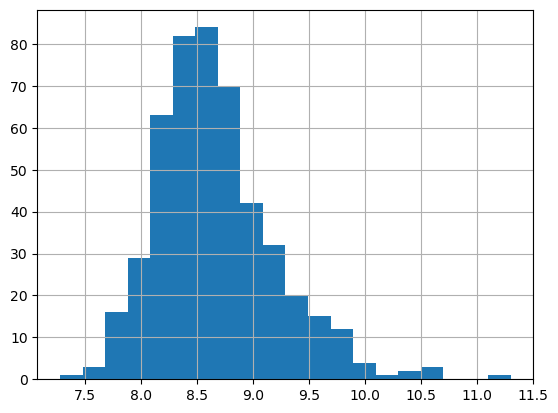

In [11]:
df['FamIncome']= df['ApplicantIncome']+ df['CoapplicantIncome']
df['FamIncome_log']= np.log(df["FamIncome"])
df['FamIncome_log'].hist(bins=20)

In [12]:
df["Gender"].fillna(df['Gender'].mode()[0], inplace = True)
df["Married"].fillna(df['Married'].mode()[0], inplace = True)
df["Self_Employed"].fillna(df['Self_Employed'].mode()[0], inplace = True)
df["Dependents"].fillna(df['Dependents'].mode()[0], inplace = True)

df.loanAmount = df.LoanAmount.fillna(df.LoanAmount.mean())
df.loanAmount_log = df.loanAmount_log.fillna(df.loanAmount_log.mean())

df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace = True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace = True)

df.isnull().sum()



/var/folders/jj/bndm17vj7nj_yf15yvvyh1kr0000gn/T/ipykernel_24183/774708001.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Gender"].fillna(df['Gender'].mode()[0], inplace = True)
/var/folders/jj/bndm17vj7nj_yf15yvvyh1kr0000gn/T/ipykernel_24183/774708001.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting va

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
loanAmount_log       0
FamIncome            0
FamIncome_log        0
dtype: int64

In [13]:
x = df.iloc[:,np.r_[1:5,9:11,13:15]].values
y = df.iloc[:,12].values
x

array([['Male', 'Yes', '1', ..., 1.0, 4.852030263919617, 6091.0],
       ['Male', 'Yes', '0', ..., 1.0, 4.189654742026425, 3000.0],
       ['Male', 'Yes', '0', ..., 1.0, 4.787491742782046, 4941.0],
       ...,
       ['Male', 'Yes', '1', ..., 1.0, 5.53338948872752, 8312.0],
       ['Male', 'Yes', '2', ..., 1.0, 5.231108616854587, 7583.0],
       ['Female', 'No', '0', ..., 0.0, 4.890349128221754, 4583.0]],
      shape=(480, 8), dtype=object)

In [14]:
y

array(['N', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'N', 'Y', 'Y', 'N', 'Y',
       'Y', 'N', 'N', 'N', 'Y', 'N', 'Y', 'Y', 'Y', 'N', 'N', 'N', 'Y',
       'N', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y',
       'N', 'N', 'N', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'N', 'N', 'N',
       'N', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'N', 'N', 'N', 'N', 'Y',
       'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'N', 'Y',
       'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'N', 'N', 'Y', 'N',
       'N', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'N', 'Y',
       'N', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'N', 'Y', 'Y', 'N', 'Y',
       'N', 'Y', 'N', 'Y', 'N', 'Y', 'Y', 'N', 'Y', 'N', 'N', 'Y', 'N',
       'Y', 'Y', 'N', 'Y', 'Y', 'N', 'N', 'Y', 'Y', 'N', 'Y', 'N', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'N', 'N', 'Y', 'Y', 'Y',
       'Y', 'N', 'Y', 'N', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y

taken loan by gender
Gender
Male      394
Female     86
Name: count, dtype: int64


/var/folders/jj/bndm17vj7nj_yf15yvvyh1kr0000gn/T/ipykernel_24183/1981263743.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Gender", data=df, palette = "Set1")


<Axes: xlabel='Gender', ylabel='count'>

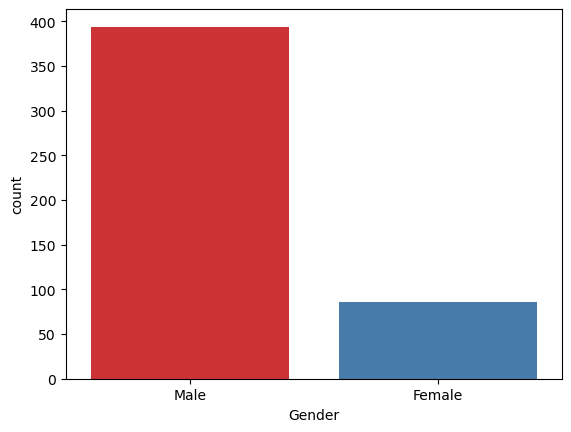

In [15]:
print("taken loan by gender")
print(df["Gender"].value_counts())
sns.countplot(x="Gender", data=df, palette = "Set1")

taken loan by marital status:
Married
Yes    311
No     169
Name: count, dtype: int64


/var/folders/jj/bndm17vj7nj_yf15yvvyh1kr0000gn/T/ipykernel_24183/1948776414.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Married", data=df, palette = "Set1")


<Axes: xlabel='Married', ylabel='count'>

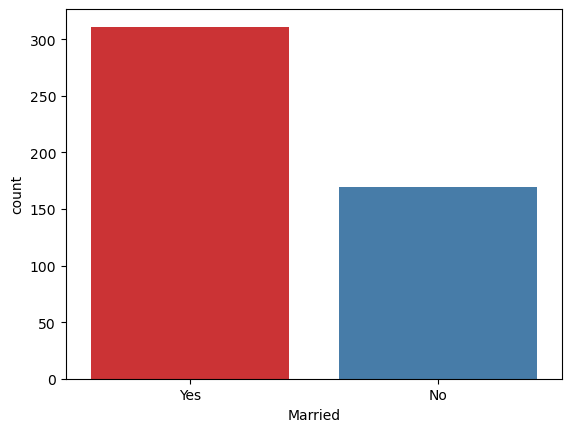

In [16]:
print("taken loan by marital status:")
print(df["Married"].value_counts())
sns.countplot(x="Married", data=df, palette = "Set1")

taken loan by dependents:
Dependents
0     274
2      85
1      80
3+     41
Name: count, dtype: int64


/var/folders/jj/bndm17vj7nj_yf15yvvyh1kr0000gn/T/ipykernel_24183/491584061.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Dependents", data=df, palette = "Set1")


<Axes: xlabel='Dependents', ylabel='count'>

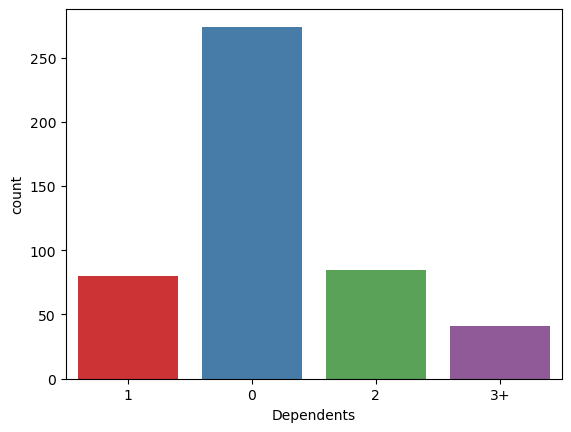

In [17]:
print("taken loan by dependents:")
print(df["Dependents"].value_counts())
sns.countplot(x="Dependents", data=df, palette = "Set1")

taken loan by self employed:
Self_Employed
No     414
Yes     66
Name: count, dtype: int64


/var/folders/jj/bndm17vj7nj_yf15yvvyh1kr0000gn/T/ipykernel_24183/3767175955.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Self_Employed", data=df, palette = "Set1")


<Axes: xlabel='Self_Employed', ylabel='count'>

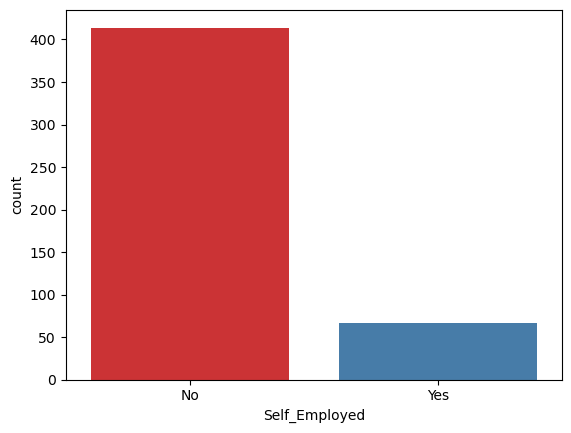

In [18]:
print("taken loan by self employed:")
print(df["Self_Employed"].value_counts())
sns.countplot(x="Self_Employed", data=df, palette = "Set1")

taken loan by self LoanAmount:
LoanAmount
120.0    13
100.0    13
110.0    13
187.0    12
128.0     9
         ..
280.0     1
240.0     1
214.0     1
59.0      1
253.0     1
Name: count, Length: 186, dtype: int64


/var/folders/jj/bndm17vj7nj_yf15yvvyh1kr0000gn/T/ipykernel_24183/3387333187.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="LoanAmount", data=df, palette = "Set1")


<Axes: xlabel='LoanAmount', ylabel='count'>

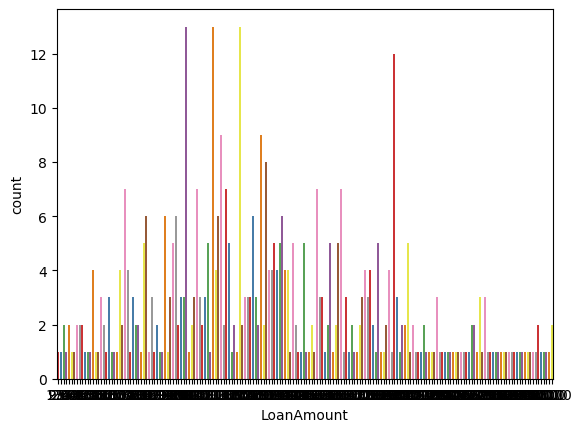

In [19]:
print("taken loan by self LoanAmount:")
print(df["LoanAmount"].value_counts())
sns.countplot(x="LoanAmount", data=df, palette = "Set1")

taken loan by self Credit history:
Credit_History
1.0    410
0.0     70
Name: count, dtype: int64


/var/folders/jj/bndm17vj7nj_yf15yvvyh1kr0000gn/T/ipykernel_24183/1315581942.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Credit_History", data=df, palette = "Set1")


<Axes: xlabel='Credit_History', ylabel='count'>

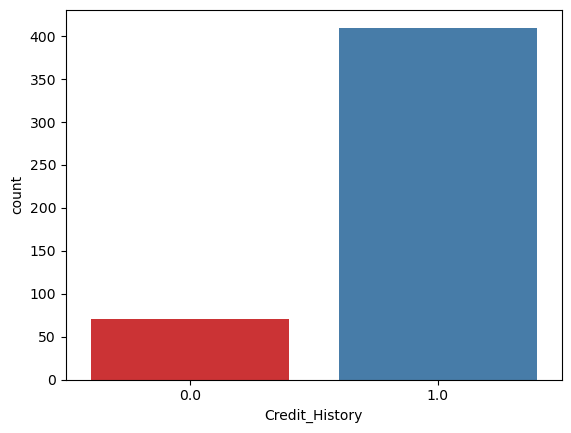

In [20]:
print("taken loan by self Credit history:")
print(df["Credit_History"].value_counts())
sns.countplot(x="Credit_History", data=df, palette = "Set1")

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=0)
from sklearn.preprocessing import LabelEncoder
LabelEncoder_x = LabelEncoder()

In [22]:
for i in range(0, 5):
    X_train[:, i] = LabelEncoder_x.fit_transform(X_train[:,i])
    X_train[:,7]= LabelEncoder_x.fit_transform(X_train[:, 7])
X_train

array([[1, 1, 3, ..., 1.0, 4.727387818712341, 32],
       [0, 0, 0, ..., 1.0, 3.828641396489095, 7],
       [0, 1, 1, ..., 1.0, 4.90527477843843, 118],
       ...,
       [1, 0, 0, ..., 1.0, 5.497168225293202, 287],
       [1, 1, 0, ..., 1.0, 4.787491742782046, 216],
       [1, 1, 0, ..., 0.0, 4.0943445622221, 5]],
      shape=(384, 8), dtype=object)

In [23]:
LabelEncoder_y = LabelEncoder()
y_train = LabelEncoder_y.fit_transform(y_train)
y_train

array([1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1,

In [29]:
for i in range(0,5):
    X_test[:,i]= LabelEncoder_x.fit_transform(X_test[:,i])
    X_test[:,7] = LabelEncoder_x.fit_transform(X_test[:,7])
    X_test

In [30]:
X_test

array([[1, 1, 0, 1, 6, 1.0, 4.890349128221754, 45],
       [1, 1, 0, 0, 6, 1.0, 5.616771097666572, 74],
       [1, 1, 0, 0, 3, 1.0, 4.290459441148391, 39],
       [1, 1, 3, 1, 6, 1.0, 5.153291594497779, 31],
       [1, 1, 0, 0, 6, 1.0, 4.90527477843843, 0],
       [1, 1, 1, 0, 6, 1.0, 5.560681631015528, 91],
       [1, 1, 2, 0, 6, 1.0, 4.997212273764115, 50],
       [1, 1, 0, 0, 6, 1.0, 4.700480365792417, 44],
       [0, 0, 0, 0, 6, 1.0, 5.41610040220442, 85],
       [1, 1, 2, 1, 6, 1.0, 4.700480365792417, 49],
       [1, 0, 0, 0, 6, 1.0, 5.231108616854587, 77],
       [1, 1, 2, 1, 6, 1.0, 4.727387818712341, 2],
       [1, 1, 2, 0, 6, 0.0, 5.552959584921617, 78],
       [1, 1, 0, 0, 6, 1.0, 4.718498871295094, 22],
       [1, 1, 1, 0, 6, 1.0, 5.043425116919247, 80],
       [1, 0, 0, 0, 6, 1.0, 4.48863636973214, 63],
       [1, 0, 0, 1, 2, 1.0, 3.2188758248682006, 18],
       [1, 1, 2, 0, 6, 1.0, 4.477336814478207, 68],
       [1, 1, 2, 1, 3, 0.0, 3.8066624897703196, 5],
       [1, 1, 2,

In [31]:
LabelEncoder_y = LabelEncoder()
y_test = LabelEncoder_y.fit_transform(y_test)
y_test

array([0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 1])

In [63]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
X_train = ss.fit_transform(X_train)
X_test = ss.fit_transform(X_test)

In [64]:
from sklearn.ensemble import RandomForestClassifier
rf_clf = RandomForestClassifier()
rf_clf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [65]:
from sklearn import metrics
y_pred = rf_clf.predict(x_test)
print("acc of random forest clf is:", metrics.accuracy_score(y_pred,y_test))
y_pred 

acc of random forest clf is: 0.71875


array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 1, 0, 1, 1])

In [66]:
from sklearn.naive_bayes import GaussianNB
nb_clf = GaussianNB()
nb_clf.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [67]:
y_predict = nb_clf.predict(X_test)
print("accuracy of naive bayes is:", metrics.accuracy_score(y_predict,y_test))

accuracy of naive bayes is: 0.7708333333333334


In [68]:
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 1, 0, 1, 1])

In [69]:
from sklearn.tree import DecisionTreeClassifier
dt_clf = DecisionTreeClassifier()
dt_clf.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [70]:
y_pred = dt_clf.predict(X_test)
print("Accuracy of decision tree is:",metrics.accuracy_score(y_pred, y_test))

Accuracy of decision tree is: 0.6666666666666666


In [71]:
from sklearn.neighbors import KNeighborsClassifier
kn_clf = KNeighborsClassifier()
kn_clf.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [72]:
y_pred= kn_clf.predict(X_test)
print("Accuracy of KN is:", metrics.accuracy_score(y_pred, y_test))

Accuracy of KN is: 0.75
